In [ ]:
#!/usr/bin/env python
# coding: utf-8

# # AMB 1D Simulation Sanity Check
# This notebook verifies that the 1D Cahn-Hilliard active model simulation (Active Model B) integrates strictly using Flux (J) operations and Dense Matrix ($N \times M$) interactions instead of FFT.
# It computes and visualizes the **Mean Local EPR Density** over a very short trajectory.

In [1]:
import sys, os
from google.colab import drive
drive.mount('/content/drive')
CNEEP_V2_ROOT = 'drive/MyDrive/CNEEP_v2/'

sys.path.append(CNEEP_V2_ROOT)
sys.path.append(os.path.join(CNEEP_V2_ROOT, 'data', 'AMB'))
sys.path.append(os.path.join(CNEEP_V2_ROOT, 'utils'))
sys.path.append(os.path.join(CNEEP_V2_ROOT, 'models'))

Mounted at /content/drive


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from generate_trajectories_1d import ActiveModelB1D

# Core Simulation Parameters
kwargs = {
    'Lx': 512,            # Domain length
    'dx': 0.8,             # Spatial resolution
    'a': 0.125,            # Active model parameter A
    'b': 0.125,            # Active model parameter B
    'kappa': 8.0,          # Gradient coefficient
    'lam': 2.0,            # Active parameter (Lambda)
    'D': 0.001,            # Noise strength (Diffusivity)
    'dt': 0.001,           # Time step
    'smooth': False,        # Smoothing for stability
    'backend': 'smooth',
    'use_gpu': torch.cuda.is_available(),
    'bc': 'periodic'
}

print(f"Using Backend: {kwargs['backend']} | GPU Enabled: {kwargs['use_gpu']}")

model = ActiveModelB1D(**kwargs)

n_seeds = 1000
n_steps = 10000
burn_in = 20000

Using Backend: smooth | GPU Enabled: True


In [22]:
# Metric Evaluator (Mean EPR Density)
print('Simulating Ensemble and Computing EPR Density On-the-Fly...')
ensemble_epr_density = model.compute_mean_epr_on_the_fly(
    n_trajectories=n_seeds, n_steps=n_steps, burn_in=burn_in, show_progress=True
)

# Print Total Mean EPR
total_epr = np.sum(ensemble_epr_density) * model.dx
print(f'Total Mean EPR across ensemble: {total_epr:.6e}')

Using Backend: torch | GPU Enabled: True
Simulating Ensemble and Computing EPR Density On-the-Fly...


Burn-in Ensemble: 100%|██████████| 20000/20000 [00:33<00:00, 598.42it/s]
                                                                                        

Total Mean EPR across ensemble: 2.829937e-01


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_379/2414966246.py:10: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('$<\sigma(x)>_{t, \mathrm{ens}}$')


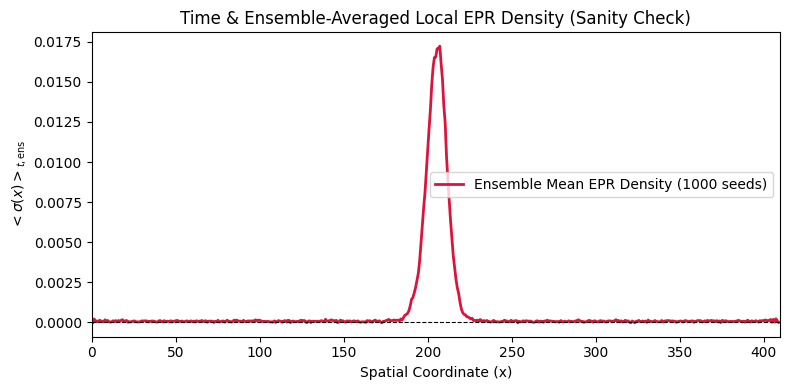

In [23]:
# Visualization: Mean Local EPR Density Only
x = np.arange(model.Lx) * model.dx

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, ensemble_epr_density, lw=2, color='crimson', label=f'Ensemble Mean EPR Density ({n_seeds} seeds)')
ax.axhline(0, color='black', ls='--', lw=0.8)

ax.set_title('Time & Ensemble-Averaged Local EPR Density (Sanity Check)')
ax.set_xlabel('Spatial Coordinate (x)')
ax.set_ylabel('$<\sigma(x)>_{t, \mathrm{ens}}$')
ax.set_xlim(0, kwargs['Lx'] * model.dx)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
dx_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
total_epr_results = []

original_dx = kwargs['dx'] # Store original dx to restore later if needed

print('Simulating for varying dx values...')
for dx_val in dx_values:
    print(f"\nSimulating with dx = {dx_val}...")
    kwargs['dx'] = dx_val
    # Re-initialize the model with the new dx value
    model = ActiveModelB1D(**kwargs)

    # Compute mean EPR density
    ensemble_epr_density = model.compute_mean_epr_on_the_fly(
        n_trajectories=n_seeds, n_steps=n_steps, burn_in=burn_in, show_progress=True
    )

    # Calculate total mean EPR
    total_epr = np.sum(ensemble_epr_density) * model.dx
    total_epr_results.append(total_epr)
    print(f'Total Mean EPR for dx = {dx_val}: {total_epr:.6e}')

# Restore original dx value
kwargs['dx'] = original_dx

Simulating for varying dx values...

Simulating with dx = 0.5...


Burn-in Ensemble:   2%|▏         | 442/20000 [02:17<1:37:27,  3.34it/s]

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(dx_values, total_epr_results, marker='o', linestyle='-', color='blue')
plt.title('Total Mean EPR vs. Spatial Resolution (dx)')
plt.xlabel('Spatial Resolution (dx)')
plt.ylabel('Total Mean EPR')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(dx_values)
plt.tight_layout()
plt.show()

Simulating for D = 0.001...


Burn-in Ensemble: 100%|██████████| 20000/20000 [00:34<00:00, 582.14it/s]


Simulating for D = 0.002...


Burn-in Ensemble: 100%|██████████| 20000/20000 [00:32<00:00, 609.26it/s]


Simulating for D = 0.02...


Burn-in Ensemble: 100%|██████████| 20000/20000 [00:32<00:00, 607.89it/s]


Simulating for D = 0.04...


Burn-in Ensemble: 100%|██████████| 20000/20000 [00:32<00:00, 606.91it/s]


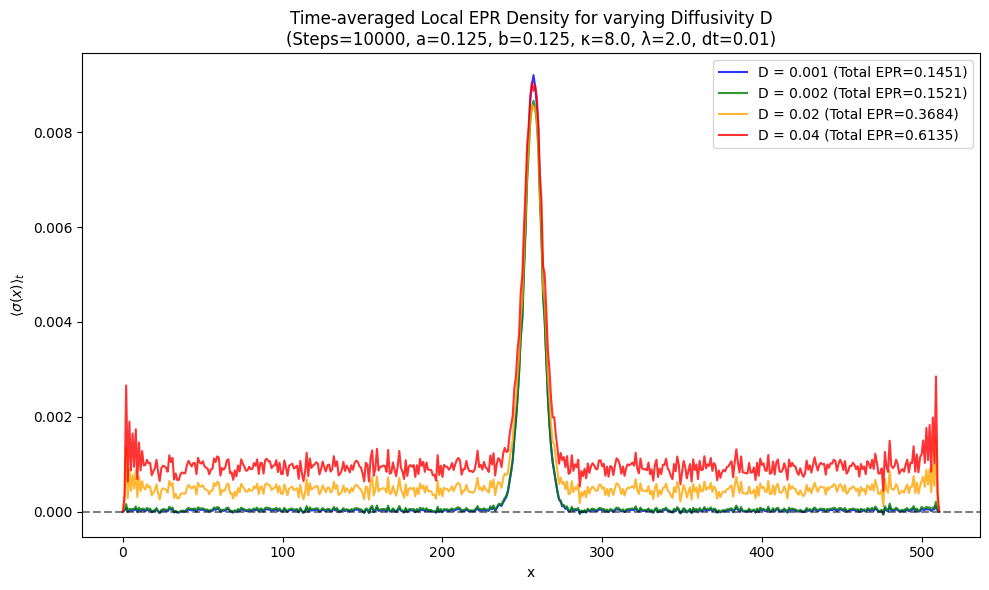

In [5]:
D_values = [0.001, 0.002, 0.02, 0.04]
n_steps = 10000
burn_in = 20000
n_seeds = 1000

plt.figure(figsize=(10, 6))
colors = ['blue', 'green', 'orange', 'red']

x = np.arange(kwargs['Lx']) * kwargs['dx']

for i, D in enumerate(D_values):
    print(f"Simulating for D = {D}...")
    kwargs['D'] = D
    model = ActiveModelB1D(**kwargs)

    epr_density = model.compute_mean_epr_on_the_fly(
        n_trajectories=n_seeds,
        n_steps=n_steps,
        burn_in=burn_in,
        show_progress=True
    )

    mean_total_epr = epr_density.sum() * kwargs['dx']
    plt.plot(x, epr_density, label=f"D = {D} (Total EPR={mean_total_epr:.4f})", color=colors[i], alpha=0.8)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('x')
plt.ylabel(r"$\langle\sigma(x)\rangle_t$")
plt.title(f"Time-averaged Local EPR Density for varying Diffusivity D\n(Steps={n_steps}, a={kwargs['a']}, b={kwargs['b']}, \u03ba={kwargs['kappa']}, \u03bb={kwargs['lam']}, dt={kwargs['dt']})")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
D_values_new = [0.001, 0.01, 0.02, 0.03, 0.04]
total_epr_for_D_results = []

original_D = kwargs['D'] # Store original D to restore later

print('Simulating for varying D values...')
for D_val in D_values_new:
    print(f"\nSimulating with D = {D_val}...")
    kwargs['D'] = D_val
    # Re-initialize the model with the new D value
    model = ActiveModelB1D(**kwargs)

    # Compute mean EPR density
    ensemble_epr_density_D = model.compute_mean_epr_on_the_fly(
        n_trajectories=n_seeds, n_steps=n_steps, burn_in=burn_in, show_progress=True
    )

    # Calculate total mean EPR
    total_epr_D = np.sum(ensemble_epr_density_D) * model.dx
    total_epr_for_D_results.append(total_epr_D)
    print(f'Total Mean EPR for D = {D_val}: {total_epr_D:.6e}')

# Restore original D value
kwargs['D'] = original_D

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(D_values_new, total_epr_for_D_results, marker='o', linestyle='-', color='green')
plt.title('Total Mean EPR vs. Diffusivity (D)')
plt.xlabel('Diffusivity (D)')
plt.ylabel('Total Mean EPR')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(D_values_new)
plt.tight_layout()
plt.show()